<a href="https://colab.research.google.com/github/vicky5859/computer-vison-/blob/main/CO-3%20AT-1%20Module-3%20Exercise%3A5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload a high-contrast image (text, checkerboard, object, etc.)


Saving 5eaa55e2-5f71-4c56-87d3-96351eb7f17b (1).png to 5eaa55e2-5f71-4c56-87d3-96351eb7f17b (1).png
Image loaded successfully!
Image size: (1086, 1448)


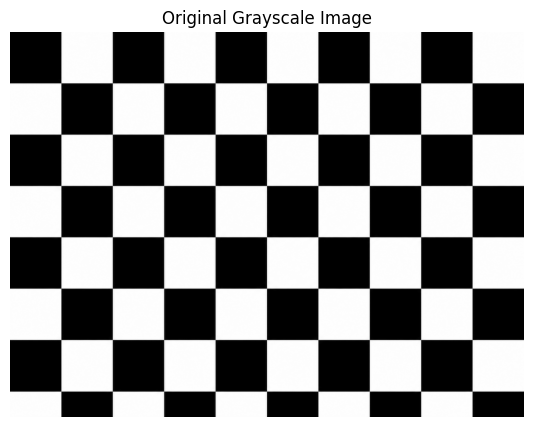

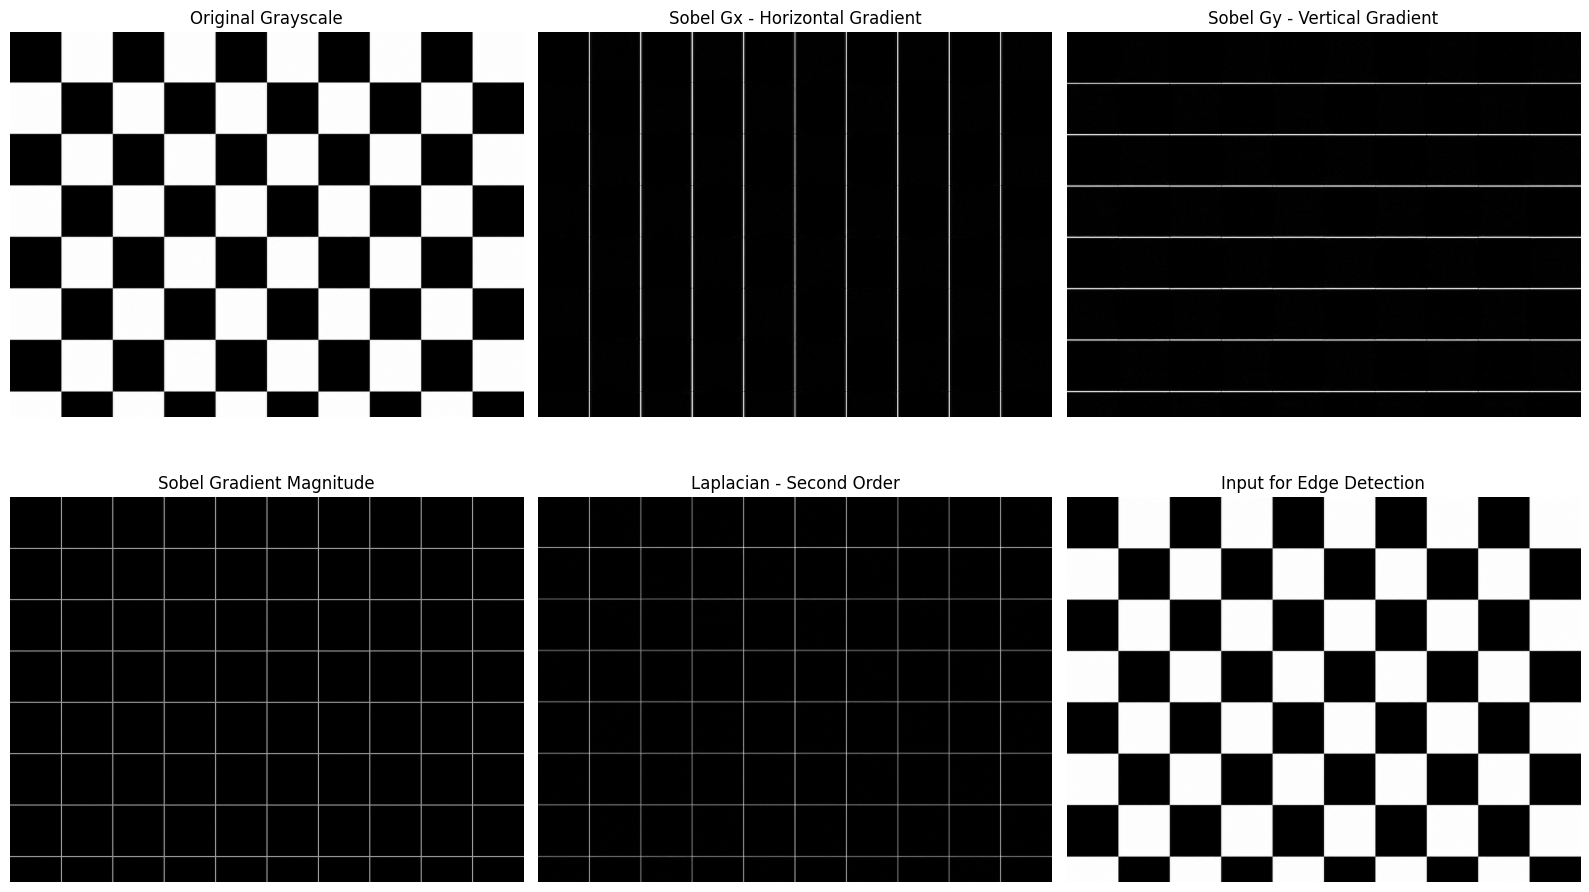

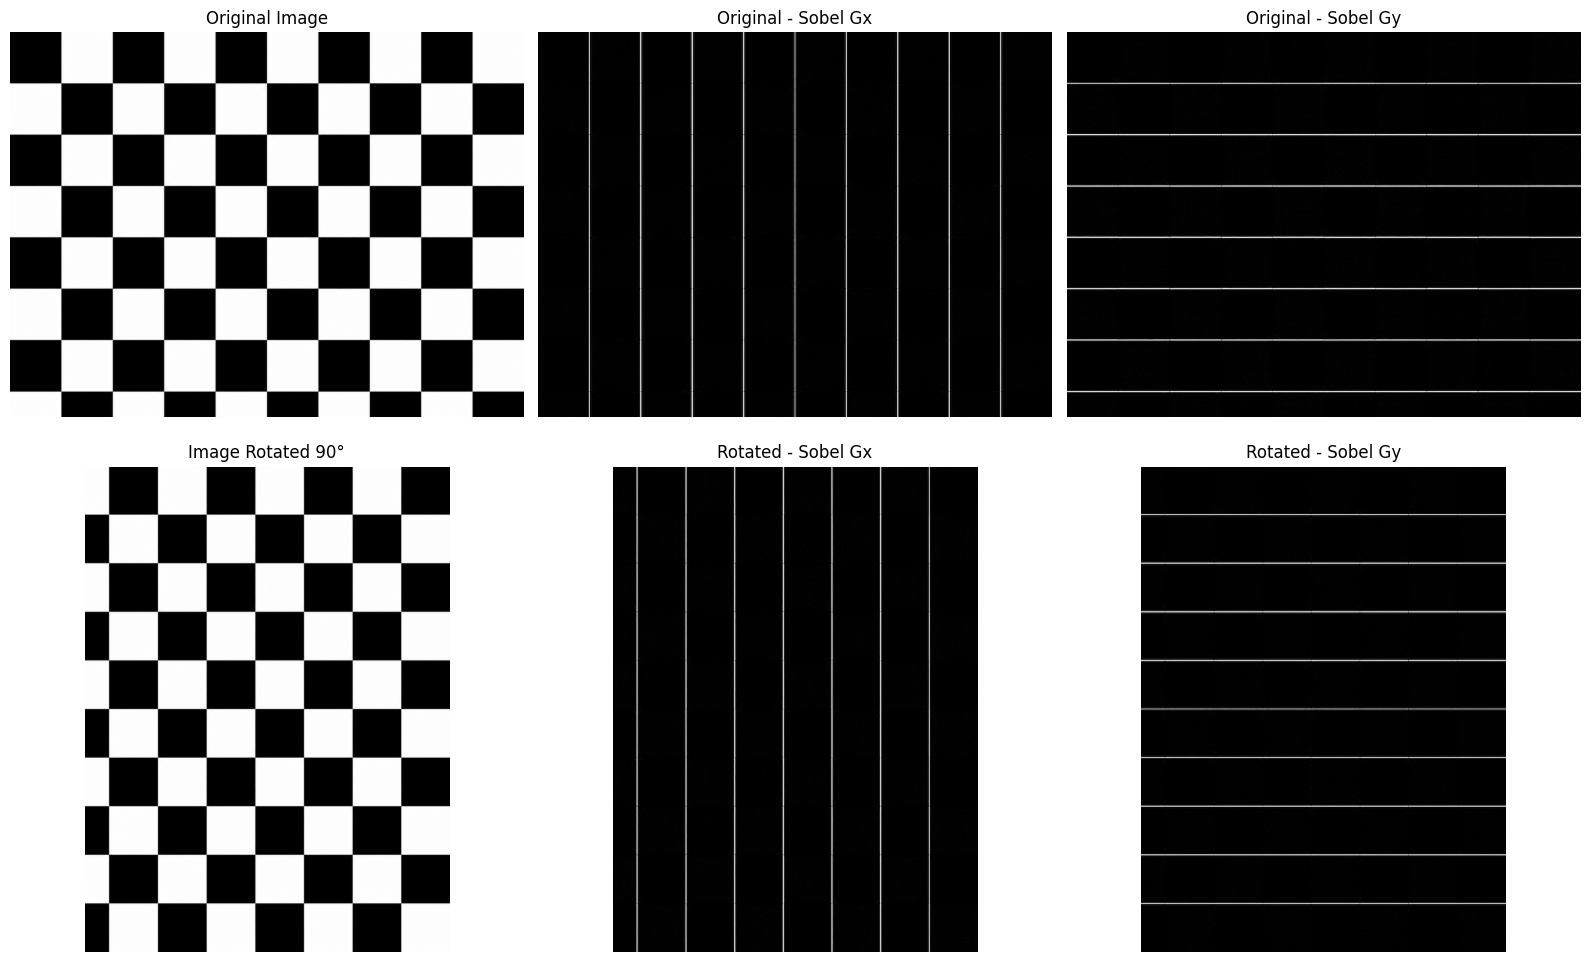

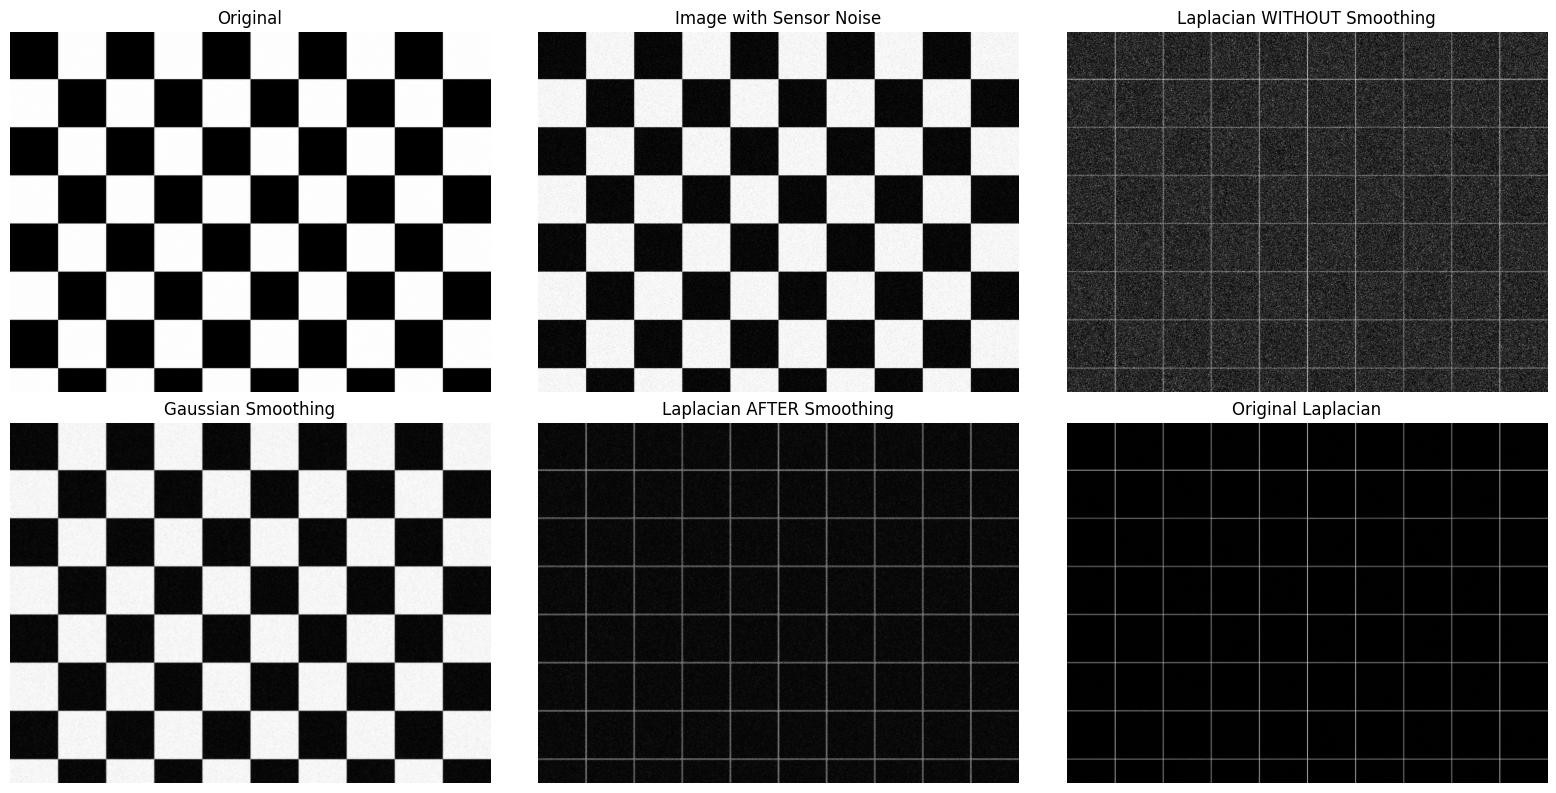


EXERCISE 5 - OBSERVATION

1. SOBEL Gx:
   Sobel Gx detects intensity changes mainly in the horizontal
   direction and highlights vertical edges.

2. SOBEL Gy:
   Sobel Gy detects intensity changes mainly in the vertical
   direction and highlights horizontal edges.

3. EFFECT OF 90° ROTATION:
   When the image is rotated by 90 degrees, the orientation
   of the detected edges changes. Therefore, the response
   between Gx and Gy changes accordingly.

4. LAPLACIAN:
   Laplacian is a second-order derivative operator. It detects
   intensity changes in multiple directions and is therefore
   considered more omnidirectional.

5. NOISE SENSITIVITY:
   Second-order derivatives amplify rapid intensity changes.
   Random sensor noise contains rapid pixel-level changes,
   so the Laplacian can strongly amplify the noise.

6. WHY SMOOTHING IS REQUIRED:
   A Gaussian smoothing step reduces high-frequency noise before
   differentiation. This prevents the derivative operator from
   interpreting

In [4]:
# ============================================================
# MODULE 3 - EXERCISE 5
# FIRST-ORDER VS SECOND-ORDER GRADIENTS
# Sobel Gx, Gy and Laplacian Edge Detection
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ============================================================
# STEP 1: UPLOAD IMAGE
# ============================================================

print("Upload a high-contrast image (text, checkerboard, object, etc.)")

uploaded = files.upload()

filename = list(uploaded.keys())[0]

# Read image
img = cv2.imread(filename)

if img is None:
    print("ERROR: Image could not be loaded.")
else:

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    print("Image loaded successfully!")
    print("Image size:", gray.shape)

    # ========================================================
    # STEP 2: DISPLAY ORIGINAL IMAGE
    # ========================================================

    plt.figure(figsize=(8, 5))
    plt.imshow(gray, cmap="gray")
    plt.title("Original Grayscale Image")
    plt.axis("off")
    plt.show()

    # ========================================================
    # STEP 3: SOBEL Gx - HORIZONTAL GRADIENT
    # ========================================================

    sobel_gx = cv2.Sobel(
        gray,
        cv2.CV_64F,
        1,
        0,
        ksize=3
    )

    sobel_gx = cv2.convertScaleAbs(sobel_gx)

    # ========================================================
    # STEP 4: SOBEL Gy - VERTICAL GRADIENT
    # ========================================================

    sobel_gy = cv2.Sobel(
        gray,
        cv2.CV_64F,
        0,
        1,
        ksize=3
    )

    sobel_gy = cv2.convertScaleAbs(sobel_gy)

    # ========================================================
    # STEP 5: SOBEL MAGNITUDE
    # ========================================================

    gx_float = cv2.Sobel(
        gray,
        cv2.CV_64F,
        1,
        0,
        ksize=3
    )

    gy_float = cv2.Sobel(
        gray,
        cv2.CV_64F,
        0,
        1,
        ksize=3
    )

    magnitude = cv2.magnitude(
        gx_float.astype(np.float32),
        gy_float.astype(np.float32)
    )

    magnitude = cv2.normalize(
        magnitude,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)

    # ========================================================
    # STEP 6: LAPLACIAN SECOND-ORDER DERIVATIVE
    # ========================================================

    laplacian = cv2.Laplacian(
        gray,
        cv2.CV_64F
    )

    laplacian = cv2.convertScaleAbs(laplacian)

    # ========================================================
    # STEP 7: DISPLAY ORIGINAL + SOBEL + LAPLACIAN
    # ========================================================

    plt.figure(figsize=(16, 10))

    plt.subplot(2, 3, 1)
    plt.imshow(gray, cmap="gray")
    plt.title("Original Grayscale")
    plt.axis("off")

    plt.subplot(2, 3, 2)
    plt.imshow(sobel_gx, cmap="gray")
    plt.title("Sobel Gx - Horizontal Gradient")
    plt.axis("off")

    plt.subplot(2, 3, 3)
    plt.imshow(sobel_gy, cmap="gray")
    plt.title("Sobel Gy - Vertical Gradient")
    plt.axis("off")

    plt.subplot(2, 3, 4)
    plt.imshow(magnitude, cmap="gray")
    plt.title("Sobel Gradient Magnitude")
    plt.axis("off")

    plt.subplot(2, 3, 5)
    plt.imshow(laplacian, cmap="gray")
    plt.title("Laplacian - Second Order")
    plt.axis("off")

    plt.subplot(2, 3, 6)
    plt.imshow(gray, cmap="gray")
    plt.title("Input for Edge Detection")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # ========================================================
    # STEP 8: ROTATE IMAGE 90 DEGREES
    # ========================================================

    rotated = cv2.rotate(
        gray,
        cv2.ROTATE_90_CLOCKWISE
    )

    # Sobel Gx on rotated image
    rotated_gx = cv2.Sobel(
        rotated,
        cv2.CV_64F,
        1,
        0,
        ksize=3
    )

    rotated_gx = cv2.convertScaleAbs(rotated_gx)

    # Sobel Gy on rotated image
    rotated_gy = cv2.Sobel(
        rotated,
        cv2.CV_64F,
        0,
        1,
        ksize=3
    )

    rotated_gy = cv2.convertScaleAbs(rotated_gy)

    # ========================================================
    # STEP 9: COMPARE ORIGINAL AND ROTATED IMAGE
    # ========================================================

    plt.figure(figsize=(16, 10))

    plt.subplot(2, 3, 1)
    plt.imshow(gray, cmap="gray")
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(2, 3, 2)
    plt.imshow(sobel_gx, cmap="gray")
    plt.title("Original - Sobel Gx")
    plt.axis("off")

    plt.subplot(2, 3, 3)
    plt.imshow(sobel_gy, cmap="gray")
    plt.title("Original - Sobel Gy")
    plt.axis("off")

    plt.subplot(2, 3, 4)
    plt.imshow(rotated, cmap="gray")
    plt.title("Image Rotated 90°")
    plt.axis("off")

    plt.subplot(2, 3, 5)
    plt.imshow(rotated_gx, cmap="gray")
    plt.title("Rotated - Sobel Gx")
    plt.axis("off")

    plt.subplot(2, 3, 6)
    plt.imshow(rotated_gy, cmap="gray")
    plt.title("Rotated - Sobel Gy")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # ========================================================
    # STEP 10: ADD NOISE TO SHOW LAPLACIAN SENSITIVITY
    # ========================================================

    noise = np.random.normal(
        0,
        20,
        gray.shape
    )

    noisy_image = gray.astype(np.float32) + noise

    noisy_image = np.clip(
        noisy_image,
        0,
        255
    ).astype(np.uint8)

    # Laplacian on noisy image
    noisy_laplacian = cv2.Laplacian(
        noisy_image,
        cv2.CV_64F
    )

    noisy_laplacian = cv2.convertScaleAbs(
        noisy_laplacian
    )

    # ========================================================
    # STEP 11: SMOOTHING BEFORE LAPLACIAN
    # ========================================================

    smoothed_image = cv2.GaussianBlur(
        noisy_image,
        (5, 5),
        0
    )

    smoothed_laplacian = cv2.Laplacian(
        smoothed_image,
        cv2.CV_64F
    )

    smoothed_laplacian = cv2.convertScaleAbs(
        smoothed_laplacian
    )

    # ========================================================
    # STEP 12: NOISE COMPARISON
    # ========================================================

    plt.figure(figsize=(16, 8))

    plt.subplot(2, 3, 1)
    plt.imshow(gray, cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2, 3, 2)
    plt.imshow(noisy_image, cmap="gray")
    plt.title("Image with Sensor Noise")
    plt.axis("off")

    plt.subplot(2, 3, 3)
    plt.imshow(noisy_laplacian, cmap="gray")
    plt.title("Laplacian WITHOUT Smoothing")
    plt.axis("off")

    plt.subplot(2, 3, 4)
    plt.imshow(smoothed_image, cmap="gray")
    plt.title("Gaussian Smoothing")
    plt.axis("off")

    plt.subplot(2, 3, 5)
    plt.imshow(smoothed_laplacian, cmap="gray")
    plt.title("Laplacian AFTER Smoothing")
    plt.axis("off")

    plt.subplot(2, 3, 6)
    plt.imshow(laplacian, cmap="gray")
    plt.title("Original Laplacian")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # ========================================================
    # FINAL OBSERVATION
    # ========================================================

    print("\n" + "=" * 70)
    print("EXERCISE 5 - OBSERVATION")
    print("=" * 70)

    print("""
1. SOBEL Gx:
   Sobel Gx detects intensity changes mainly in the horizontal
   direction and highlights vertical edges.

2. SOBEL Gy:
   Sobel Gy detects intensity changes mainly in the vertical
   direction and highlights horizontal edges.

3. EFFECT OF 90° ROTATION:
   When the image is rotated by 90 degrees, the orientation
   of the detected edges changes. Therefore, the response
   between Gx and Gy changes accordingly.

4. LAPLACIAN:
   Laplacian is a second-order derivative operator. It detects
   intensity changes in multiple directions and is therefore
   considered more omnidirectional.

5. NOISE SENSITIVITY:
   Second-order derivatives amplify rapid intensity changes.
   Random sensor noise contains rapid pixel-level changes,
   so the Laplacian can strongly amplify the noise.

6. WHY SMOOTHING IS REQUIRED:
   A Gaussian smoothing step reduces high-frequency noise before
   differentiation. This prevents the derivative operator from
   interpreting random noise as false edges.

7. CONCLUSION:
   Sobel provides directional edge information through Gx and Gy.
   Laplacian provides an approximately omnidirectional response,
   but it is more sensitive to noise. Therefore, smoothing is
   normally performed before applying derivative-based edge
   detection.
    """)

    print("=" * 70)
    print("EXERCISE 5 COMPLETED SUCCESSFULLY!")
    print("=" * 70)